In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from utils import load_set
from model_functions import evaluate_model_side_by_side
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import pickle

In [3]:
X_train, y_train = load_set('data/df_train_cleaned.csv', with_FS = True)
X_test, y_test = load_set('data/df_test_cleaned.csv', with_FS = True)

In [4]:
LR = LogisticRegression(
            penalty="l2",
            solver="saga",
            C=0.001,
            random_state=47,
            max_iter=1000,
            n_jobs=-1,
            class_weight="balanced",
        )

XGB = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    max_depth=4,
    learning_rate=0.001,
    min_child_weight=10,
    subsample=0.5,
    colsample_bytree=0.5,
    colsample_bylevel=0.5,
    colsample_bynode=0.5,
    gamma=20,
    reg_alpha=20,
    reg_lambda=20,
    scale_pos_weight=sum(y_train==0)/sum(y_train==1),
    # use_label_encoder=False,
    random_state=47,
    n_jobs=-1
)

In [5]:
models = [LR, XGB]
names = ['Regresja logistyczna', 'XGBoost']

###############
Regresja logistyczna

=== Metryki Train vs Test ===


,precision_train,precision_test,recall_train,recall_test,f1-score_train,f1-score_test,support_train,support_test
0,0.934708,0.927835,0.69432,0.689655,0.796778,0.791209,1567.0,522.0
1,0.246855,0.235849,0.67382,0.641026,0.361335,0.344828,233.0,78.0



=== Metryki Globalne Probabilistyczne ===


,Train,Test
Metric,,
ROC AUC,0.7696,0.7460
PR AUC,0.3733,0.3799
KS Stat,0.4042,0.3988
Log Loss,0.5924,0.6495
Brier Score,0.2023,0.2036
Accuracy,0.6917,0.6833


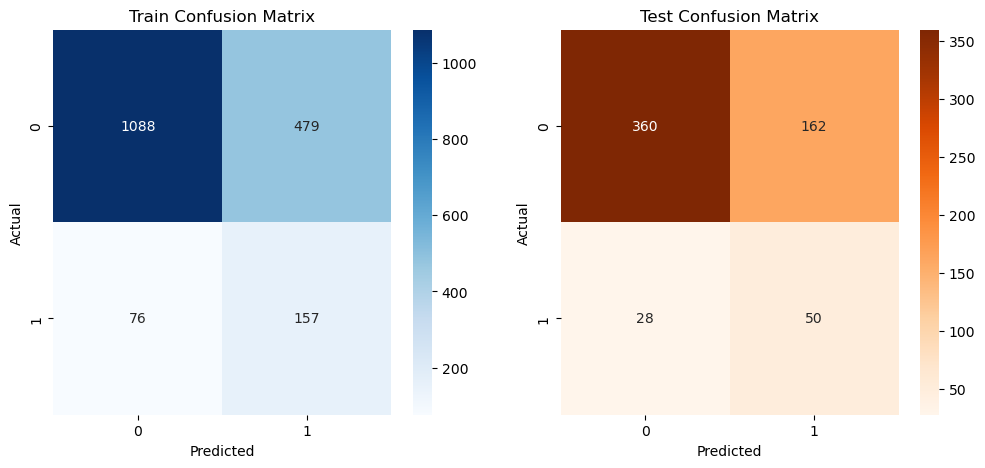

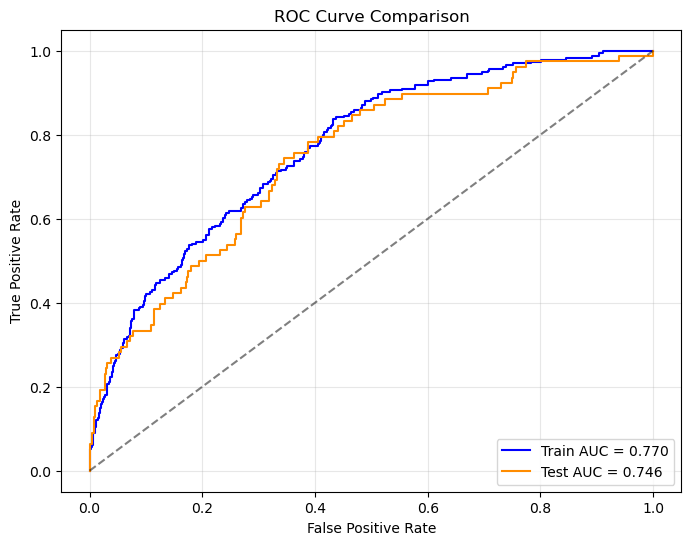

###############
XGBoost

=== Metryki Train vs Test ===


,precision_train,precision_test,recall_train,recall_test,f1-score_train,f1-score_test,support_train,support_test
0,0.938938,0.938667,0.677090,0.674330,0.786800,0.784838,1567.0,522.0
1,0.244776,0.244444,0.703863,0.705128,0.363234,0.363036,233.0,78.0



=== Metryki Globalne Probabilistyczne ===


,Train,Test
Metric,,
ROC AUC,0.7713,0.7581
PR AUC,0.3562,0.3412
KS Stat,0.4007,0.3989
Log Loss,0.6644,0.6655
Brier Score,0.2357,0.2362
Accuracy,0.6806,0.6783


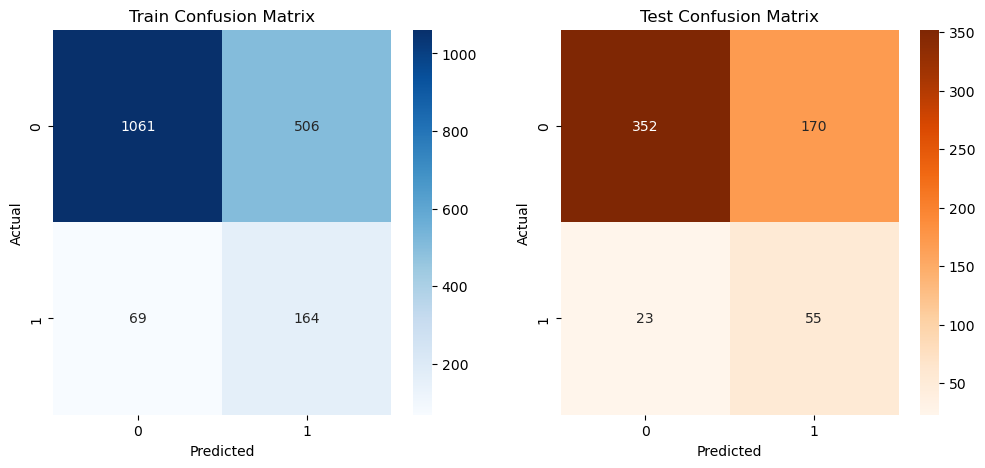

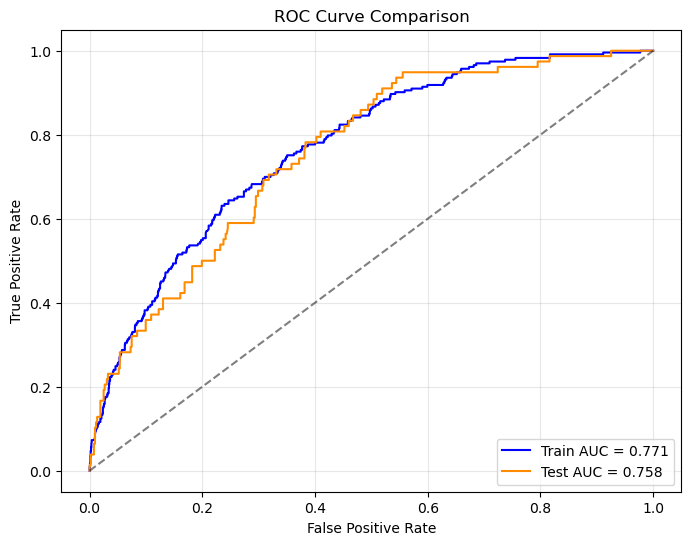

In [6]:
THRESHOLD = 0.5
for model, name in zip(models, names):
    model.fit(X_train, y_train)
    evaluate_model_side_by_side(model,name, X_train, y_train, X_test, y_test, threshold=THRESHOLD)

# Tuning

In [7]:
fbeta = make_scorer(fbeta_score, beta=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=47)

param_grid_lr = {
    "penalty": ["l2", 'l1'],
    "C": [0.001, 0.0001, 0.0005],
    "solver": ["saga"],
    "class_weight": ["balanced", None],
}


from scipy.stats import uniform, randint

param_distributions_xgb = {
    # Regularization - większe wartości niż obecnie
    'reg_alpha': uniform(20, 80),          # od 20 do 100
    'reg_lambda': uniform(20, 180),        # od 20 do 200
    'gamma': uniform(20, 80),              # od 20 do 100
    
    # Złożoność drzewa
    'max_depth': randint(3, 7),            # lekko wokół obecnej wartości 4
    'min_child_weight': randint(8, 20),    # zwiększa odporność na przeuczenie
    
    # Sampling (bardziej konserwatywne, mniejsze wartości)
    'subsample': uniform(0.4, 0.3),        # 0.4–0.7
    'colsample_bytree': uniform(0.4, 0.3), # 0.4–0.7
    'colsample_bylevel': uniform(0.4, 0.3),
    'colsample_bynode': uniform(0.4, 0.3),
    
    # Learning rate — nie za duży, żeby model był stabilny
    'learning_rate': uniform(0.0005, 0.001),  # 0.0005–0.0015
    
    # Liczba estymatorów – przy małym learning rate można próbować więcej
    'n_estimators': randint(300, 800)
}


# Regresja logistyczna
grid_lr = GridSearchCV(
    LR,
    param_grid_lr,
    scoring=fbeta,
    cv=cv,
    n_jobs=-1,
    verbose=2
)


random_xgb = RandomizedSearchCV(
    estimator=XGB,
    param_distributions=param_distributions_xgb,
    n_iter=300,
    scoring=fbeta,
    cv=cv,
    verbose=2,
    random_state=47,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)
random_xgb.fit(X_train, y_train)


print("Najlepsze parametry LR:", grid_lr.best_params_)
print("Najlepsze parametry XGB:", random_xgb.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Najlepsze parametry LR: {'C': 0.0005, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}
Najlepsze parametry XGB: {'colsample_bylevel': 0.6381063823097928, 'colsample_bynode': 0.6638152165342569, 'colsample_bytree': 0.4010984037321885, 'gamma': 39.98807446838143, 'learning_rate': 0.0006378383133833138, 'max_depth': 5, 'min_child_weight': 14, 'n_estimators': 444, 'reg_alpha': 23.734060693587544, 'reg_lambda': 27.04466947920436, 'subsample': 0.6495181206415913}


In [8]:
LR = grid_lr.best_estimator_
XGB = random_xgb.best_estimator_

with open('models/LR_params.pkl', 'wb') as f:
    pickle.dump(LR.get_params(), f)
with open('models/XGB_params.pkl', 'wb') as f:
    pickle.dump(XGB.get_params(), f)
with open("models/LogisticRegression.pkl", "wb") as f:
    pickle.dump(LR,f)
with open("models/XGBoost.pkl", "wb") as f:
    pickle.dump(XGB, f)

In [9]:
models = [LR, XGB]
names = ['Regresja logistyczna', 'XGBoost']

###############
Regresja logistyczna

=== Metryki Train vs Test ===


,precision_train,precision_test,recall_train,recall_test,f1-score_train,f1-score_test,support_train,support_test
0,0.935626,0.928947,0.677090,0.676245,0.785635,0.782705,1567.0,522.0
1,0.240240,0.231818,0.686695,0.653846,0.355951,0.342282,233.0,78.0



=== Metryki Globalne Probabilistyczne ===


,Train,Test
Metric,,
ROC AUC,0.7570,0.7453
PR AUC,0.3553,0.3714
KS Stat,0.3729,0.4039
Log Loss,0.6122,0.6403
Brier Score,0.2110,0.2108
Accuracy,0.6783,0.6733


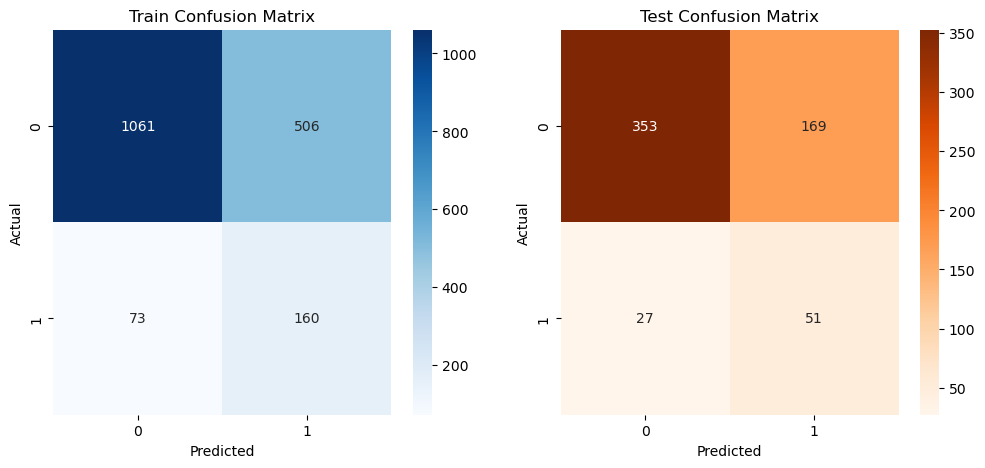

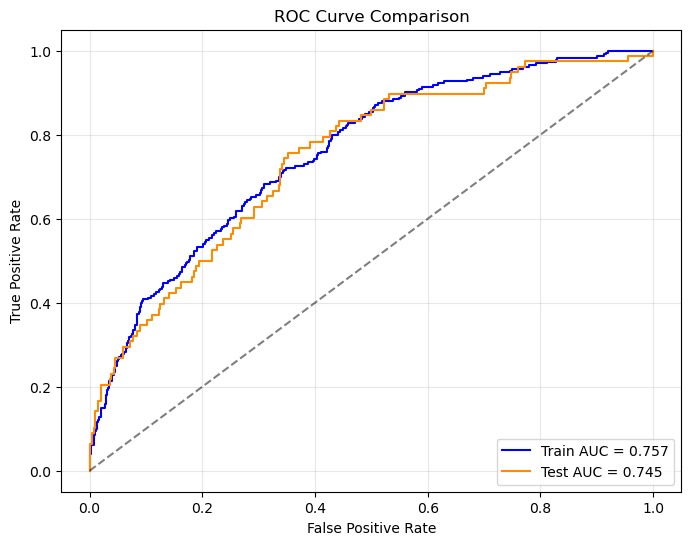

###############
XGBoost

=== Metryki Train vs Test ===


,precision_train,precision_test,recall_train,recall_test,f1-score_train,f1-score_test,support_train,support_test
0,0.936945,0.933155,0.673261,0.668582,0.783513,0.779018,1567.0,522.0
1,0.240356,0.234513,0.695279,0.679487,0.357222,0.348684,233.0,78.0



=== Metryki Globalne Probabilistyczne ===


,Train,Test
Metric,,
ROC AUC,0.7615,0.7606
PR AUC,0.3374,0.3403
KS Stat,0.3924,0.4182
Log Loss,0.6688,0.6695
Brier Score,0.2379,0.2382
Accuracy,0.6761,0.6700


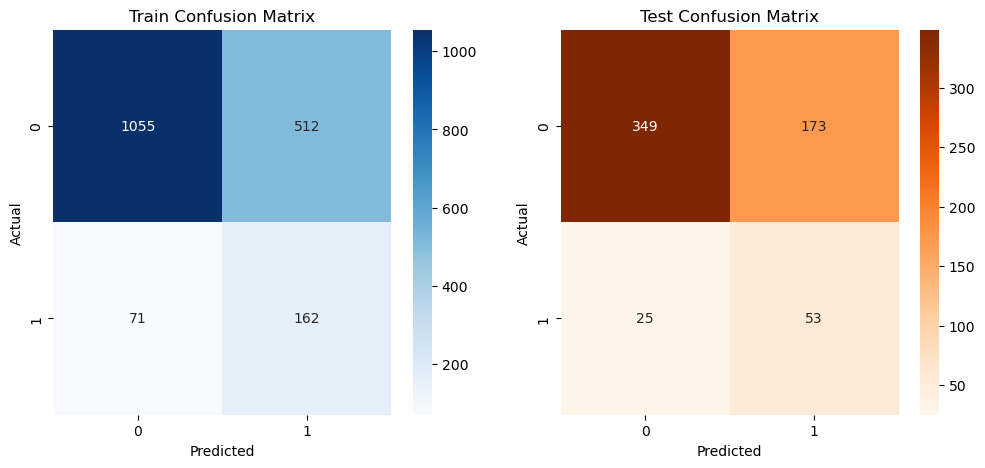

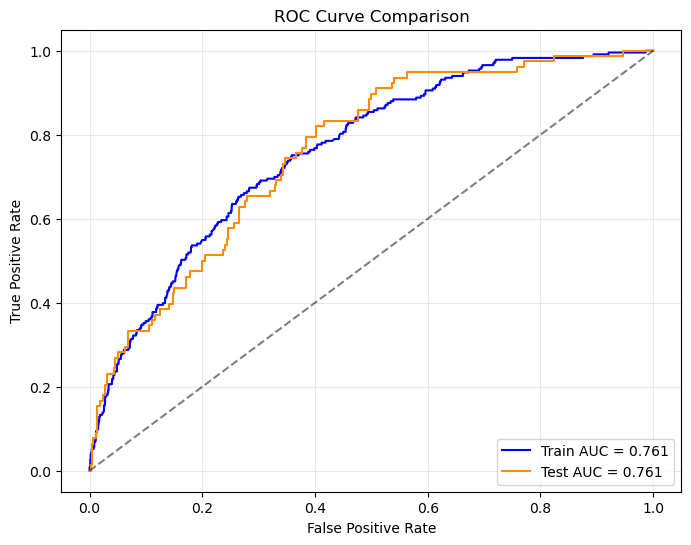

In [10]:
THRESHOLD = 0.5
for model, name in zip(models, names):
    model.fit(X_train, y_train)
    evaluate_model_side_by_side(model,name, X_train, y_train, X_test, y_test, threshold=THRESHOLD)